# <div style="color:white;display:fill;border-radius:5px;background-color:#555555;font-family:Arial"><p style="padding: 8px;color:white;"><b>Introduction</b></p></div>

This study evaluates the abalone dataset and attempts to apply a clustering technique to see whether the predictive models can be improved with the clusters. This study finds that if you apply good clustering you can indeed improve the performance of a predictive model.

In [ ]:
import numpy as np
import pandas as pd
from pandas_profiling import ProfileReport

from IPython.core.display import display, HTML

import seaborn as sns
import matplotlib.pyplot as plt
import warnings

# Configure Jupyter Notebook
pd.set_option('display.max_columns', None) 
pd.set_option('display.max_rows', 500) 
pd.set_option('display.expand_frame_repr', False)
display(HTML("<style>div.output_scroll { height: 35em; }</style>"))

%matplotlib inline
%config InlineBackend.figure_format ='retina'

warnings.filterwarnings('ignore')

In [ ]:
# df = pd.read_csv('abaloneCleaned.csv')
df = pd.read_csv('../input/abalone-dataset/abalone.csv')

# <div style="color:white;display:fill;border-radius:5px;background-color:#555555;font-family:Arial"><p style="padding: 8px;color:white;"><b>Explore</b></p></div>

The abalone dataset is a old one where the age (or number of rings) is predicted from features that can be more easily measured. The features are:

 - Sex / nominal / -- / M, F, and I (infant)
 - Length / continuous / mm / Longest shell measurement
 - Diameter / continuous / mm / perpendicular to length
 - Height / continuous / mm / with meat in shell
 - Whole weight / continuous / grams / whole abalone
 - Shucked weight / continuous / grams / weight of meat
 - Viscera weight / continuous / grams / gut weight (after bleeding)
 - Shell weight / continuous / grams / after being dried
 - Rings / integer / -- / +1.5 gives the age in years

To start the exploration the data quality is checked

In [ ]:
df.info()

This tells us that there is no missing values

In [ ]:
df.head(10)

This gives us a glimpse of the data where we can see mostly numerical features with one categorical feature

In [ ]:
df.describe(include='all').T

The descriptive features above shows us the distribution of the values, where we can see a few outliers in the numerical data (for instance the maximum for Height and shucked weight). We can apply clamping, or simply use models/methods that are less sensitive to outliers. For instance scaling using a standard scaler and modelling using something like a random forest. 

In [ ]:
%%time
profile = ProfileReport(df,
                        title="Profiling Report",
                        dataset={"description": "This profiling report was generated for Carl Kirstein",
                                 "copyright_holder": "Carl Kirstein",
                                 "copyright_year": "2022",
                                },
                        explorative=True,
                       )
profile
# profile.to_file("Tutorial 2.html")

The profiling report above shows us that the data quality is not problematic. 

In [ ]:
plt.figure(figsize=(10,10))
sns.set_style('white')
plot_kws={"s": 1}
g = sns.pairplot(
             df,
             # kind='reg',
             diag_kind='hist',
             corner=False,
             # plot_kws=dict(scatter_kws=dict(s=5)),
             palette='cividis',
             hue='Rings'
            )

# g = g.map_diag(sns.kdeplot, lw=2)
# g = g.map_offdiag(sns.kdeplot, lw=0.5)
plt.show()

The pairplot (SPLOM) above shows us that there are not clear clusters at a first glance. We are looking for clusters, so this will require us to transform the data. PCA is immediately considered. 

We also see that it is not easy to distinguish the number of rings simply through correlation to any single features, although there is a suggestion that the age of the abalone is related to its size. 

In [ ]:
plt.figure(figsize=(10,10))
threshold = 0.5
sns.set_style("whitegrid", {"axes.facecolor": ".0"})
df_cluster2 = df.corr()
mask = df_cluster2.where((abs(df_cluster2) >= threshold)).isna()
plot_kws={"s": 1}
sns.heatmap(df_cluster2,
#             figsize=(15,15),
            cmap='RdYlBu',
            annot=True,
            mask=mask,
            linewidths=0.2, 
            linecolor='lightgrey').set_facecolor('white')

The correlation heatmap above shows us that there are highly correlated features, i.e. length<->diameter and whole weight -> shucked weight - viscera weight - shell-weight. 

Diameter and whole weight can then be dropped.

In [ ]:
%%time

def corrdot(*args, **kwargs):
    corr_r = args[0].corr(args[1])
    corr_text = f"{corr_r:2.2f}".replace("0.", ".")
    ax = plt.gca()
    ax.set_axis_off()
    marker_size = abs(corr_r) * 10000
    ax.scatter([.5], [.5], marker_size, [corr_r], alpha=0.6, cmap='coolwarm',
               vmin=-1, vmax=1, transform=ax.transAxes)
    font_size = abs(corr_r) * 40 + 5
    ax.annotate(corr_text, [.5, .5,],  xycoords="axes fraction",
                ha='center', va='center', fontsize=font_size)

sns.set(style='white', font_scale=1.6)
g = sns.PairGrid(df, aspect=1.4, diag_sharey=False)
g.map_lower(sns.regplot, lowess=True, ci=False, line_kws={'color': 'black','lw': 1.5}, scatter_kws={'s':3,'alpha':0.1,'color':'gray'})
g.map_diag(sns.distplot, kde_kws={'color': 'black'},hist_kws={'color':'gray','alpha':1,})
g.map_upper(corrdot)

The correlation reg-plot above gives us a nicer view of the correlations and the structure of the data in one.

In [ ]:
plt.style.use('seaborn-white')
plt.rcParams['figure.figsize']=15,15 
plt.rcParams['font.family'] = 'Calibri'
plt.rcParams['font.size'] = 12
plt.rcParams['lines.linewidth'] = 0.5
plt.rcParams['axes.labelsize']=12
plt.rcParams['xtick.labelsize']=12
plt.rcParams['ytick.labelsize']=12
plt.rcParams['legend.fontsize']=12

plt.figure(figsize=(10, 15))

# colors = sns.color_palette()

rows = 7
cols = 1
i = 0

i += 1
plt.subplot(rows, cols, i)
_ = sns.violinplot(data=df, x='Rings', y='Length')

i += 1
plt.subplot(rows, cols, i)
_ = sns.violinplot(data=df, x='Rings', y='Diameter')

i += 1
plt.subplot(rows, cols, i)
_ = sns.violinplot(data=df, x='Rings', y='Height')

i += 1
plt.subplot(rows, cols, i)
_ = sns.violinplot(data=df, x='Rings', y='Whole weight')

i += 1
plt.subplot(rows, cols, i)
_ = sns.violinplot(data=df, x='Rings', y='Shucked weight')

i += 1
plt.subplot(rows, cols, i)
_ = sns.violinplot(data=df, x='Rings', y='Viscera weight')

i += 1
plt.subplot(rows, cols, i)
_ = sns.violinplot(data=df, x='Rings', y='Shell weight')

sns.despine

The figures above tries to determine through violin plots whether clusters are easily discernable. In this state it is still not clear. The abalone seems to grow up to a point and then its size remains more or less constant.

# <div style="color:white;display:fill;border-radius:5px;background-color:#555555;font-family:Arial"><p style="padding: 8px;color:white;"><b>Clustering Tendency</b></p></div>

The next step in the quest to find clusters will be to apply clustering tendency evaluations. 
We start with the Hopkins statistic that tells us that there's clusters when the value is >0.75

In [ ]:
from random import sample
from numpy.random import uniform
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import scale

# function to compute hopkins's statistic for the dataframe X
def hopkins_statistic(X,k=2):
    
    X=X.values  #convert dataframe to a numpy array
    X = scale(X)
    sample_size = int(X.shape[0]*0.05) #0.05 (5%) based on paper by Lawson and Jures
    
    
    #a uniform random sample in the original data space
    X_uniform_random_sample = uniform(X.min(axis=0), X.max(axis=0) ,(sample_size , X.shape[1]))
    
    
    
    #a random sample of size sample_size from the original data X
    random_indices=sample(range(0, X.shape[0], 1), sample_size)
    X_sample = X[random_indices]
   
    
    #initialise unsupervised learner for implementing neighbor searches
    neigh = NearestNeighbors(n_neighbors=k)
    nbrs=neigh.fit(X)
    
    #u_distances = nearest neighbour distances from uniform random sample
    u_distances , u_indices = nbrs.kneighbors(X_uniform_random_sample , n_neighbors=k)
    u_distances = u_distances[: , 0] #distance to the first (nearest) neighbour
    
    #w_distances = nearest neighbour distances from a sample of points from original data X
    w_distances , w_indices = nbrs.kneighbors(X_sample , n_neighbors=k)
    #distance to the second nearest neighbour (as the first neighbour will be the point itself, with distance = 0)
    w_distances = w_distances[: , 1]
    
 
    
    u_sum = np.sum(u_distances)
    w_sum = np.sum(w_distances)
    
    #compute and return hopkins' statistic
    H = u_sum/ (u_sum + w_sum)
    return H
    

In [ ]:
df.columns

In [ ]:
df = pd.get_dummies(df)

In [ ]:
from sklearn.preprocessing import StandardScaler
float_columns = [x for x in df.columns if x not in ['Sex', 'Rings']]
sc = StandardScaler()
df2 = df.copy()
df[float_columns] = sc.fit_transform(df[float_columns])
df.head()

In [ ]:
# X=df[['Length' , 'Diameter' , 'Height', 'Whole weight','Shucked weight','Viscera weight','Shell weight']] #independent attributes
X = df.drop(['Rings'],axis=1)
y=df['Rings'] #class attribute

In [ ]:
# call the function on the iris dataset
H=hopkins_statistic(X,3)
print('Hopkins statistic: '+str(H))

The Hopkins statistic is greater than 0.75, therefore there is a strong indication that there are clusters. 

In [ ]:
# !pip uninstall pyclustertend -y
# !pip install pyclustertend

The next step is a VAT where we check whether there are clustering tendencies. 

In [ ]:
from typing import Tuple

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import pairwise_distances
from numba import njit


def vat(data: np.ndarray, return_odm: bool = False, figure_size: Tuple = (10, 10)):
    """VAT means Visual assessment of tendency. basically, it allow to asses cluster tendency
    through a map based on the dissimilarity matrix.
    Parameters
    ----------
    data : matrix
        numpy array
    return_odm : return the Ordered dissimilarity Matrix
        boolean (default to False)
    figure_size : size of the VAT.
        tuple (default to (10,10))
    Return
    -------
    ODM : matrix
        the ordered dissimilarity matrix plotted.
    """

    ordered_dissimilarity_matrix = compute_ordered_dissimilarity_matrix(data)

    _, ax = plt.subplots(figsize=figure_size)
    ax.imshow(
        ordered_dissimilarity_matrix,
        cmap="coolwarm",
        vmin=0,
        vmax=np.max(ordered_dissimilarity_matrix),
    )

    if return_odm is True:
        return ordered_dissimilarity_matrix


@njit(cache=True)
def compute_ordered_dis_njit(matrix_of_pairwise_distance: np.ndarray):  # pragma: no cover
    """
    The ordered dissimilarity matrix is used by visual assessment of tendency. It is a just a a reordering
    of the dissimilarity matrix.
    Parameter
    ----------
    x : matrix
        numpy array
    Return
    -------
    ODM : matrix
        the ordered dissimilarity matrix
    """

    # Step 1 :

    observation_path = np.zeros(matrix_of_pairwise_distance.shape[0], dtype="int")

    list_of_int = np.zeros(matrix_of_pairwise_distance.shape[0], dtype="int")

    index_of_maximum_value = np.argmax(matrix_of_pairwise_distance)

    column_index_of_maximum_value = (
        index_of_maximum_value // matrix_of_pairwise_distance.shape[1]
    )

    list_of_int[0] = column_index_of_maximum_value
    observation_path[0] = column_index_of_maximum_value

    K = np.linspace(
        0,
        matrix_of_pairwise_distance.shape[0] - 1,
        matrix_of_pairwise_distance.shape[0],
    ).astype(np.int32)

    J = np.delete(K, column_index_of_maximum_value)

    for r in range(1, matrix_of_pairwise_distance.shape[0]):

        p, q = (-1, -1)

        mini = np.max(matrix_of_pairwise_distance)

        for candidate_p in observation_path[0:r]:
            for candidate_j in J:
                if matrix_of_pairwise_distance[candidate_p, candidate_j] < mini:
                    p = candidate_p
                    q = candidate_j
                    mini = matrix_of_pairwise_distance[p, q]

        list_of_int[r] = q
        observation_path[r] = q
        ind_q = np.where(J == q)[0][0]
        J = np.delete(J, ind_q)

    # Step 3

    ordered_matrix = np.zeros(matrix_of_pairwise_distance.shape)

    for column_index_of_maximum_value in range(ordered_matrix.shape[0]):
        for j in range(ordered_matrix.shape[1]):
            ordered_matrix[
                column_index_of_maximum_value, j
            ] = matrix_of_pairwise_distance[
                list_of_int[column_index_of_maximum_value], list_of_int[j]
            ]

    # Step 4 :

    return ordered_matrix


def compute_ordered_dissimilarity_matrix(x: np.ndarray) -> np.ndarray:
    matrix_of_pairwise_distance = pairwise_distances(x)
    dis_matrix = compute_ordered_dis_njit(matrix_of_pairwise_distance)
    return dis_matrix


def ivat(data: np.ndarray, return_odm: bool = False, figure_size: Tuple = (10, 10)):
    """iVat return a visualisation based on the Vat but more reliable and easier to
    interpret.
    Parameters
    ----------
    data : matrix
        numpy array
    return_odm : return the Ordered dissimilarity Matrix
            boolean (default to False)
    figure_size : size of the VAT.
        tuple (default to (10,10))
    Return
    -------
    D_prim : matrix
        the ivat ordered dissimilarity matrix
    """

    ordered_matrix = compute_ivat_ordered_dissimilarity_matrix(data)

    _, ax = plt.subplots(figsize=figure_size)
    ax.imshow(ordered_matrix, cmap="coolwarm", vmin=0, vmax=np.max(ordered_matrix))

    if return_odm is True:
        return ordered_matrix


def compute_ivat_ordered_dissimilarity_matrix(x: np.ndarray):
    """The ordered dissimilarity matrix is used by ivat. It is a just a a reordering
    of the dissimilarity matrix.
    Parameters
    ----------
    x : matrix
        numpy array
    Return
    -------
    D_prim : matrix
        the ordered dissimilarity matrix
    """

    ordered_matrix = compute_ordered_dissimilarity_matrix(x)
    re_ordered_matrix = np.zeros((ordered_matrix.shape[0], ordered_matrix.shape[0]))

    for r in range(1, ordered_matrix.shape[0]):
        # Step 1 : find j for which D[r,j] is minimum and j ipn [1:r-1]

        j = np.argmin(ordered_matrix[r, 0:r])

        # Step 2 :

        re_ordered_matrix[r, j] = ordered_matrix[r, j]
        re_ordered_matrix[j, r] = ordered_matrix[r, j]

        # Step 3 : for c : 1, r-1 with c !=j
        c_tab = np.array(range(0, r))
        c_tab = c_tab[c_tab != j]

        for c in c_tab:
            re_ordered_matrix[r, c] = max(ordered_matrix[r, j], re_ordered_matrix[j, c])
            re_ordered_matrix[c, r] = re_ordered_matrix[r, c]

    return re_ordered_matrix

First the data is scaled through standardization

Then the VAT is performed

In [ ]:
X=np.array(df)

In [ ]:
%%time
ivat(X)

In [ ]:
%%time
vat(X)

So the VAT confirms that there are clusters. And it seems that there are three distinct clusters in there somewhere. So the next sections will be to see whether we can get those distinct clusters. 

# <div style="color:white;display:fill;border-radius:5px;background-color:#555555;font-family:Arial"><p style="padding: 8px;color:white;"><b>Data Transformation - PCA</b></p></div>

We saw previously with the pairplot and correlation plot that the clusters are not distinct. Therefore a PCA is done.

In [ ]:
from sklearn.decomposition import PCA

# Create principal components
pca = PCA()
# X_pca = pca.fit_transform(df[['Length','Diameter','Height','Whole weight','Shucked weight','Viscera weight','Shell weight']])
X_pca = pca.fit_transform(df[['Length','Height','Shucked weight','Viscera weight','Shell weight','Sex_I','Sex_F','Sex_M']])

# Convert to dataframe
component_names = [f"PC{i+1}" for i in range(X_pca.shape[1])]
X_pca = pd.DataFrame(X_pca, columns=component_names)

X_pca.head(10)

When the pairplot (SPLOM) is repeated for the Princpal Components, the three clusters magically appears in PC2 and even PC3

In [ ]:
plt.figure(figsize=(15,15))
sns.set_style('white')
plot_kws={"s": 1}
g = sns.pairplot(
             X_pca,
             # kind='reg',
             diag_kind='hist',
             corner=False,
             # plot_kws=dict(scatter_kws=dict(s=5)),
             palette='cividis',
             # hue='kmeans'
            )

# g = g.map_diag(sns.kdeplot, lw=2)
# g = g.map_offdiag(sns.kdeplot, lw=0.5)
plt.show()

The shape for PC2 is familiar when visiting https://scikit-learn.org/stable/modules/clustering.html

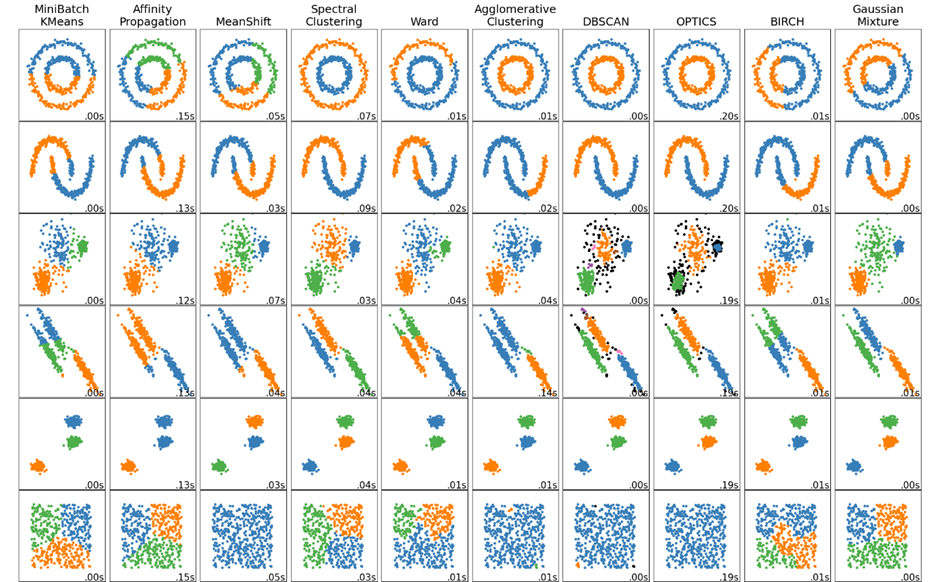;

The cluster layout is similar to the 3rd last row in the figure above. The OPTICS method seems to be an good approach that could deal with the shape of the clusters, although the best to use is probably the spectral clustering technique. 

In [ ]:
def plot_variance(pca, width=8, dpi=100):
    # Create figure
    fig, axs = plt.subplots(1, 2)
    n = pca.n_components_
    grid = np.arange(1, n + 1)
    # Explained variance
    evr = pca.explained_variance_ratio_
    axs[0].bar(grid, evr)
    axs[0].set(
        xlabel="Component", title="% Explained Variance", ylim=(0.0, 1.0)
    )
    # Cumulative Variance
    cv = np.cumsum(evr)
    axs[1].plot(np.r_[0, grid], np.r_[0, cv], "o-")
    axs[1].set(
        xlabel="Component", title="% Cumulative Variance", ylim=(0.0, 1.0)
    )
    # Set up figure
    fig.set(figwidth=8, dpi=100)
    return axs

In [ ]:
plt.style.use('seaborn-white')
plt.rcParams['figure.figsize']=5,5 
plt.rcParams['font.family'] = 'Calibri'
plt.rcParams['font.size'] = 12
plt.rcParams['lines.linewidth'] = 1
plt.rcParams['axes.labelsize']=12
plt.rcParams['xtick.labelsize']=12
plt.rcParams['ytick.labelsize']=12
plt.rcParams['legend.fontsize']=12
plot_variance(pca);

In [ ]:
pca.explained_variance_ratio_

The explained variance ratio has ranked the principal components with PC1 accounting for more than 60% of the variance followed by PC2 with 19%. The variance is probably sufficiently addressed by only 5 components.

In [ ]:
from sklearn.feature_selection import mutual_info_regression

def make_mi_scores(X, y, discrete_features):
    mi_scores = mutual_info_regression(X, y, discrete_features=discrete_features)
    mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
    mi_scores = mi_scores.sort_values(ascending=False)
    return mi_scores

In [ ]:
y = df['Rings']
mi_scores = make_mi_scores(X_pca, y, discrete_features=False)
mi_scores

When a mutual information evaluation however is performed, it is clear that PC2 is the dominant component for information gain.  

In [ ]:
# component loadings or weights (correlation coefficient between original variables and the component) 
# component loadings represents the elements of the eigenvector
# the squared loadings within the PCs always sums to 1
loadings = pca.components_
num_pc = pca.n_features_
pc_list = ["PC"+str(i) for i in list(range(1, num_pc+1))]
loadings_df = pd.DataFrame.from_dict(dict(zip(pc_list, loadings)))
loadings_df['variable'] = df[['Length','Height','Shucked weight','Viscera weight','Shell weight','Sex_I','Sex_F','Sex_M']].columns.values
loadings_df = loadings_df.set_index('variable')
loadings_df

In [ ]:
plt.figure(figsize=(10,10))
threshold = 0.
sns.set_style("whitegrid", {"axes.facecolor": ".0"})
df_cluster2 = loadings_df
mask = df_cluster2.where((abs(df_cluster2) >= threshold)).isna()
plot_kws={"s": 1}
sns.heatmap(df_cluster2,
#             figsize=(15,15),
            cmap='RdYlBu',
            annot=True,
            mask=mask,
            linewidths=0.2, 
            linecolor='lightgrey').set_facecolor('white')

PC1 is most affected by Length, Height, and the Weight features. This means that these features most strongly determine the age of the abalones. It is interesting that the correlation of any one feature is not dominant, nor are any of them particularly strong. The conclusion is then that all those the features are necessary to predict the age of the abalones. 

The 2nd biggest feature, PC2, accounts for 19% of the variance observed. This is dominated by the labels in Sex, which is also apparent in PC3.

Therefore, while most of the predictive power is with the dimensions of the abalone, and a significant portion is with the sex of the abalone. 


# <div style="color:white;display:fill;border-radius:5px;background-color:#555555;font-family:Arial"><p style="padding: 8px;color:white;"><b>K-Means</b></p></div>

The go to clustering method is kmeans, although it is probably not fully suited to the cluster shapes observed thus far. It should be informative nonetheless. The first k-means application is without the principal components. We'll start with the 3 clusters, but we'll shows throughout this notebook why 3 cluster have been selected. 

In [ ]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans = kmeans.fit(df[float_columns])

In [ ]:
df['kmeans'] = kmeans.predict(df[float_columns])

In [ ]:
# create and fit a range of models: 
km_list = list()
for clust in range(1, 21):
    km = KMeans(n_clusters=clust, random_state=42)
    km = km.fit(df[float_columns])
    km_list.append(pd.Series({'clusters': clust,
                             'inertia':km.inertia_,
                             'model':km}))

In [ ]:
plt.style.use('seaborn-white')
plt.rcParams['figure.figsize']=5,5 
plt.rcParams['font.family'] = 'Calibri'
plt.rcParams['font.size'] = 12
plt.rcParams['lines.linewidth'] = 0.5
plt.rcParams['axes.labelsize']=12
plt.rcParams['xtick.labelsize']=12
plt.rcParams['ytick.labelsize']=12
plt.rcParams['legend.fontsize']=12

plot_data = (pd.concat(km_list, axis=1)
             .T
             [['clusters','inertia']]
             .set_index('clusters'))

ax = plot_data.plot(marker='o', ls='-', color='steelblue')
ax.set_title('K-means')
ax.set_xticks(range(0, 21, 2))
ax.set_xlim(0,21)
ax.set(xlabel='Cluster', ylabel='Inertia');

The elbow method is attempted and it is not clear. This k-means approach suggests only 2 clusters.

In [ ]:
# sns.set_color_codes()
# km = KMeans(cluster_number).fit(data_norm)
# data_norm["label"] = km.labels_.astype(str)

cluster_number = df['kmeans'].nunique()
centroids = pd.DataFrame(kmeans.cluster_centers_)
centroids.columns = df[float_columns].columns
centroids["label"] = [str(n)+" centroid" for n in range(cluster_number)]
# full_ds = pd.concat([df, centroids], ignore_index=True)
g = sns.PairGrid(centroids, hue="label", palette='cividis',             
                 # hue_order=[str(n) for n in range(cluster_number)]+[str(n)+" centroid" for n in range(cluster_number)],
                 hue_order=[str(n)+" centroid" for n in range(cluster_number)],
                 hue_kws={"s": [ 150 for n in range(cluster_number)]+[500 for n in range(cluster_number)],
                          "marker": [ 'o' for n in range(cluster_number)]+['o' for n in range(cluster_number)]}
                )
g.map(plt.scatter, linewidth=1, edgecolor="w")
g.add_legend()

    

The centroids are not evenly spaced which is probably accurate. 

In [ ]:
centroids

# <div style="color:white;display:fill;border-radius:5px;background-color:#555555;font-family:Arial"><p style="padding: 8px;color:white;"><b>K-Means PCA</b></p></div>

the previous section did k-means on the orginal features, this section focuses more on the principal components. 

In [ ]:
from sklearn.cluster import KMeans
kmeansPCA = KMeans(n_clusters=3, random_state=42)
kmeansPCA = kmeansPCA.fit(X_pca)
X_pca['kmeans PCA'] = kmeansPCA.labels_
X_pca.head()

In [ ]:
df2 = pd.concat([df.reset_index(drop=True),X_pca],axis=1)
df2.head()

In [ ]:
df['kmeans PCA'] = df2['kmeans PCA']

In [ ]:
plt.figure(figsize=(15,15))
sns.set_style('white')
plot_kws={"s": 1}
g = sns.pairplot(
             df2[['Length','Height','Whole weight','Shucked weight','Viscera weight','Shell weight','Rings','PC1','PC2','PC3','kmeans PCA']],
             # kind='reg',
             diag_kind='hist',
             corner=False,
             # plot_kws=dict(scatter_kws=dict(s=5)),
             palette='cividis',
             hue='kmeans PCA'
            )

# g = g.map_diag(sns.kdeplot, lw=2)
# g = g.map_offdiag(sns.kdeplot, lw=0.5)
plt.show()

Okay, so it turns out that k-means also does not pick up the clusters that well simply because theyre too elongated after standardization for the spherical approach of k-means. Another approach is needed. 

In [ ]:
# create and fit a range of models: 
km_list = list()
for clust in range(1, 21):
    kmPCA2 = KMeans(n_clusters=clust, random_state=42)
    kmPCA2 = kmPCA2.fit(X_pca)
    km_list.append(pd.Series({'clusters': clust,
                             'inertia':kmPCA2.inertia_,
                             'model':kmPCA2}))

In [ ]:
plt.style.use('seaborn-white')
plt.rcParams['figure.figsize']=5,5 
plt.rcParams['font.family'] = 'Calibri'
plt.rcParams['font.size'] = 12
plt.rcParams['lines.linewidth'] = 0.5
plt.rcParams['axes.labelsize']=12
plt.rcParams['xtick.labelsize']=12
plt.rcParams['ytick.labelsize']=12
plt.rcParams['legend.fontsize']=12

plot_data = (pd.concat(km_list, axis=1)
             .T
             [['clusters','inertia']]
             .set_index('clusters'))

ax = plot_data.plot(marker='o', ls='-', color='steelblue')
ax.set_title('K-means with PCA')
ax.set_xticks(range(0, 21, 2))
ax.set_xlim(0,21)
ax.set(xlabel='Cluster', ylabel='Inertia');

What we do find however is that with the principal components identified, the elbow is at 3 clusters. This gives further credibility to the choice of three clusters. 

# <div style="color:white;display:fill;border-radius:5px;background-color:#555555;font-family:Arial"><p style="padding: 8px;color:white;"><b>Agglomerative Clustering</b></p></div>

a cluster method that could work on the set is agglomerative clustering. The three clusters identified thus far is used for the analysis.  

In [ ]:
from sklearn.cluster import AgglomerativeClustering
ag = AgglomerativeClustering(n_clusters=3, linkage='ward', compute_full_tree=True)
ag = ag.fit(df[float_columns])
df['agglom'] = ag.fit_predict(df[float_columns])

In [ ]:
plt.style.use('seaborn-white')
plt.rcParams['figure.figsize']=8,8 
plt.rcParams['font.family'] = 'Calibri'
plt.rcParams['font.size'] = 12
plt.rcParams['lines.linewidth'] = 1
plt.rcParams['axes.labelsize']=12
plt.rcParams['xtick.labelsize']=12
plt.rcParams['ytick.labelsize']=12
plt.rcParams['legend.fontsize']=12

from scipy.cluster.hierarchy import dendrogram
from sklearn.cluster import AgglomerativeClustering


def plot_dendrogram(model, **kwargs):
    # Create linkage matrix and then plot the dendrogram

    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    # Plot the corresponding dendrogram
    dendrogram(linkage_matrix, **kwargs)


# iris = load_iris()
# X = iris.data

# setting distance_threshold=0 ensures we compute the full tree.
model = AgglomerativeClustering(linkage='ward',distance_threshold=0, n_clusters=None)

model = model.fit(df[float_columns])
plt.title("Hierarchical Clustering Dendrogram")


plot_dendrogram(model, truncate_mode="level", p=5)
plt.xlabel("Number of points in node (or index of point if no parenthesis).")
sns.despine()
plt.show()

The chart above does not give us a nice view of how to separate the clusters, although one could argue that the seperation at three clusters is a feasible place, as the number of clusters rapidly increase with diminishing inter cluster distances. 

# <div style="color:white;display:fill;border-radius:5px;background-color:#555555;font-family:Arial"><p style="padding: 8px;color:white;"><b>OPTICS</b></p></div>

OPTICS is one of the best suited for the cluster shape observed in the PCA. It should also work without the PCA transformation in identifying the 3 clusters observed so far.   

In [ ]:
from sklearn.cluster import OPTICS
km = OPTICS(min_samples=100, xi=0.03, min_cluster_size=0.05)
km = km.fit(X_pca)
X_pca['OPTICS'] = km.labels_

In [ ]:
plt.figure(figsize=(15,15))
sns.set_style('white')
plot_kws={"s": 1}
g = sns.pairplot(
             X_pca.drop(['kmeans PCA'],axis=1),
             # kind='reg',
             diag_kind='hist',
             corner=False,
             # plot_kws=dict(scatter_kws=dict(s=5)),
             palette='cividis',
             hue='OPTICS'
            )

# g = g.map_diag(sns.kdeplot, lw=2)
# g = g.map_offdiag(sns.kdeplot, lw=0.5)
plt.show()

The pairplot (SPLOM) above shows that the OPTICS method clearly distinguishes the clusters. So this method seems to be the best so far. 

In [ ]:
X=df[['Length' , 'Shucked weight','Viscera weight','Shell weight','Sex_I','Sex_F','Sex_M']] #independent attributes
y=df['Rings'] #class attribute

# from sklearn.preprocessing import scale
# X = scale(X)

from sklearn.cluster import OPTICS
km = OPTICS(min_samples=100, xi=0.03, min_cluster_size=0.05)
km = km.fit(X)

In [ ]:
df['OPTICS'] = km.labels_
X_pca['OPTICS'] = km.labels_

In [ ]:
# (df[['Sex', 'kmeans','Rings']].groupby(['kmeans','Sex']).agg(pd.Series.mode).rename(columns={0: 'number'}))
(df[['OPTICS','Rings']].groupby(['OPTICS']).count().rename(columns={"Rings": 'Number instances'}))

In [ ]:
# # (df[['Sex', 'agglom','Rings']].groupby(['agglom','Sex']).agg(pd.Series.mode).rename(columns={0: 'number'}))
(df[['OPTICS','Rings']].groupby(['OPTICS']).agg(pd.Series.mode).rename(columns={"Rings": 'Most frequent Rings'}))

In [ ]:
X=df[['Length' , 'Shucked weight','Viscera weight','Shell weight','Sex_I','Sex_F','Sex_M']] #independent attributes
y=df['Rings'] #class attribute

from sklearn.preprocessing import scale
X = scale(X)

In [ ]:
# Authors: Shane Grigsby <refuge@rocktalus.com>
#          Adrin Jalali <adrin.jalali@gmail.com>
# License: BSD 3 clause

from sklearn.cluster import OPTICS, cluster_optics_dbscan
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np

# clust = OPTICS(min_samples=10, xi=0.05, min_cluster_size=0.05)
clust = OPTICS(min_samples=100, xi=0.03, min_cluster_size=0.05)

# Run the fit
clust.fit(X)

labels_050 = cluster_optics_dbscan(
    reachability=clust.reachability_,
    core_distances=clust.core_distances_,
    ordering=clust.ordering_,
    eps=0.5,
)
labels_200 = cluster_optics_dbscan(
    reachability=clust.reachability_,
    core_distances=clust.core_distances_,
    ordering=clust.ordering_,
    eps=2,
)

space = np.arange(len(X))
reachability = clust.reachability_[clust.ordering_]
labels = clust.labels_[clust.ordering_]

plt.figure(figsize=(10, 7))
G = gridspec.GridSpec(2, 3)
ax1 = plt.subplot(G[0, :])

# Reachability plot
colors = ["g.", "r.", "b.", "y.", "c."]
for klass, color in zip(range(0, 5), colors):
    Xk = space[labels == klass]
    Rk = reachability[labels == klass]
    ax1.plot(Xk, Rk, color, alpha=0.3)
ax1.plot(space[labels == -1], reachability[labels == -1], "k.", alpha=0.3)
ax1.plot(space, np.full_like(space, 2.0, dtype=float), "k-", alpha=0.5)
ax1.plot(space, np.full_like(space, 0.5, dtype=float), "k-.", alpha=0.5)
ax1.set_ylabel("Reachability (epsilon distance)")
ax1.set_title("Reachability Plot")

plt.tight_layout()
plt.show()

The reachability plot above clearly shows the three clusters that have been identified. The nice thing about OPTICS is that you do not tell it how many clusters there are, it does so automatically.

# <div style="color:white;display:fill;border-radius:5px;background-color:#555555;font-family:Arial"><p style="padding: 8px;color:white;"><b>Spectral Clustering</b></p></div>

In [ ]:
from sklearn.cluster import SpectralClustering
clustering = SpectralClustering(n_clusters=3,
                                assign_labels='discretize',
                                random_state=0).fit(X)
X_pca['spectral'] = clustering.labels_

In [ ]:
df['spectral'] = X_pca['spectral']

In [ ]:
plt.figure(figsize=(15,15))
sns.set_style('white')
plot_kws={"s": 1}
g = sns.pairplot(
             X_pca,
             # kind='reg',
             diag_kind='hist',
             corner=False,
             # plot_kws=dict(scatter_kws=dict(s=5)),
             palette='cividis',
             hue='spectral'
            )

# g = g.map_diag(sns.kdeplot, lw=2)
# g = g.map_offdiag(sns.kdeplot, lw=0.5)
plt.show()

In [ ]:
# (df[['Sex', 'kmeans','Rings']].groupby(['kmeans','Sex']).agg(pd.Series.mode).rename(columns={0: 'number'}))
(df[['spectral','Rings']].groupby(['spectral']).count().rename(columns={"Rings": 'Number instances'}))

In [ ]:
# # (df[['Sex', 'agglom','Rings']].groupby(['agglom','Sex']).agg(pd.Series.mode).rename(columns={0: 'number'}))
(df[['spectral','Rings']].groupby(['spectral']).agg(pd.Series.mode).rename(columns={"Rings": 'Most frequent Rings'}))

# <div style="color:white;display:fill;border-radius:5px;background-color:#555555;font-family:Arial"><p style="padding: 8px;color:white;"><b>Visualization</b></p></div>

Ini this section we investigate the clustering more visually through SPLOMs and parallel coordinate plots

# <div style="color:white;display:fill;border-radius:5px;background-color:#555555;font-family:Arial"><p style="padding: 8px;color:white;"><b>SPLOM</b></p></div>

In [ ]:
df.head(10)

In [ ]:
plt.figure(figsize=(15,15))
sns.set_style('white')
plot_kws={"s": 1}
g = sns.pairplot(
             df[['Length','Diameter','Height','Whole weight','Shucked weight','Viscera weight','Shell weight','Rings','kmeans PCA']],
             # kind='reg',
             diag_kind='hist',
             corner=False,
             # plot_kws=dict(scatter_kws=dict(s=5)),
             palette='cividis',
             hue='kmeans PCA'
            )

# g = g.map_diag(sns.kdeplot, lw=2)
# g = g.map_offdiag(sns.kdeplot, lw=0.5)
plt.show()

In [ ]:
plt.figure(figsize=(15,15))
sns.set_style('white')
plot_kws={"s": 1}
g = sns.pairplot(
             X_pca.drop(['OPTICS'],axis=1),
             # kind='reg',
             diag_kind='hist',
             corner=False,
             # plot_kws=dict(scatter_kws=dict(s=5)),
             palette='cividis',
             hue='kmeans PCA'
            )

# g = g.map_diag(sns.kdeplot, lw=2)
# g = g.map_offdiag(sns.kdeplot, lw=0.5)
plt.show()

In [ ]:
plt.figure(figsize=(15,15))
sns.set_style('white')
plot_kws={"s": 1}
g = sns.pairplot(
             df[['Length','Diameter','Height','Whole weight','Shucked weight','Viscera weight','Shell weight','Rings','agglom']],
             # kind='reg',
             diag_kind='hist',
             corner=False,
             # plot_kws=dict(scatter_kws=dict(s=5)),
             palette='cividis',
             hue='agglom'
            )

# g = g.map_diag(sns.kdeplot, lw=2)
# g = g.map_offdiag(sns.kdeplot, lw=0.5)
plt.show()

In [ ]:
plt.figure(figsize=(15,15))
sns.set_style('white')
plot_kws={"s": 1}
g = sns.pairplot(
             df[['Length','Diameter','Height','Whole weight','Shucked weight','Viscera weight','Shell weight','Rings','OPTICS']],
             # kind='reg',
             diag_kind='hist',
             corner=False,
             # plot_kws=dict(scatter_kws=dict(s=5)),
             palette='cividis',
             hue='OPTICS'
            )

# g = g.map_diag(sns.kdeplot, lw=2)
# g = g.map_offdiag(sns.kdeplot, lw=0.5)
plt.show()

In [ ]:
plt.figure(figsize=(15,15))
sns.set_style('white')
plot_kws={"s": 1}
g = sns.pairplot(
             X_pca.drop(['kmeans PCA'],axis=1),
             # kind='reg',
             diag_kind='hist',
             corner=False,
             # plot_kws=dict(scatter_kws=dict(s=5)),
             palette='cividis',
             hue='OPTICS'
            )

# g = g.map_diag(sns.kdeplot, lw=2)
# g = g.map_offdiag(sns.kdeplot, lw=0.5)
plt.show()

## <div style="color:white;display:fill;border-radius:5px;background-color:#aaaaaa;font-family:Arial"><p style="padding: 8px;color:white;"><b>Parallel Coordinate Plot</b></p></div>

In [ ]:
df2['kmeans'] = df['kmeans'].astype(str)
df2['agglom'] = df['agglom'].astype(str)
df2['OPTICS'] = df['OPTICS'].astype(str)

In [ ]:
# plt.style.use('seaborn-white')
# plt.rcParams['figure.figsize']=10,10 
# plt.rcParams['font.family'] = 'Calibri'
# plt.rcParams['font.size'] = 12
# plt.rcParams['lines.linewidth'] = 0.5
# plt.rcParams['axes.labelsize']=12
# plt.rcParams['xtick.labelsize']=12
# plt.rcParams['ytick.labelsize']=12
# plt.rcParams['legend.fontsize']=12

# from pandas.plotting import parallel_coordinates

# # data = pandas.read_csv(r'C:\Python27\Lib\site-packages\pandas\tests\data\iris.csv', sep=',')
# parallel_coordinates(df2[['Length','Diameter','Height','Whole weight','Shucked weight','Viscera weight','Shell weight','Rings','kmeans']], 
#                      'kmeans',
#                     colormap='cividis')
# plt.show()

In [ ]:
# plt.style.use('seaborn-white')
# plt.rcParams['figure.figsize']=10,10 
# plt.rcParams['font.family'] = 'Calibri'
# plt.rcParams['font.size'] = 12
# plt.rcParams['lines.linewidth'] = 0.5
# plt.rcParams['axes.labelsize']=12
# plt.rcParams['xtick.labelsize']=12
# plt.rcParams['ytick.labelsize']=12
# plt.rcParams['legend.fontsize']=12

# from pandas.plotting import parallel_coordinates
# parallel_coordinates(df2[['Length','Diameter','Height','Whole weight','Shucked weight','Viscera weight','Shell weight','Rings','kmedoids']], 
#                      'kmedoids',
#                     colormap='cividis')
# plt.show()

In [ ]:
plt.style.use('seaborn-white')
plt.rcParams['figure.figsize']=10,10 
plt.rcParams['font.family'] = 'Calibri'
plt.rcParams['font.size'] = 12
plt.rcParams['lines.linewidth'] = 0.5
plt.rcParams['axes.labelsize']=12
plt.rcParams['xtick.labelsize']=12
plt.rcParams['ytick.labelsize']=12
plt.rcParams['legend.fontsize']=12

from pandas.plotting import parallel_coordinates

# data = pandas.read_csv(r'C:\Python27\Lib\site-packages\pandas\tests\data\iris.csv', sep=',')
parallel_coordinates(df2[['Length','Diameter','Height','Whole weight','Shucked weight','Viscera weight','Shell weight','Rings','kmeans PCA']], 
                     'kmeans PCA',
                    colormap='cividis')
plt.show()

In [ ]:
plt.style.use('seaborn-white')
plt.rcParams['figure.figsize']=10,10 
plt.rcParams['font.family'] = 'Calibri'
plt.rcParams['font.size'] = 10
plt.rcParams['lines.linewidth'] = 0.5
plt.rcParams['axes.labelsize']=10
plt.rcParams['xtick.labelsize']=10
plt.rcParams['ytick.labelsize']=10
plt.rcParams['legend.fontsize']=10

from pandas.plotting import parallel_coordinates

# data = pandas.read_csv(r'C:\Python27\Lib\site-packages\pandas\tests\data\iris.csv', sep=',')
parallel_coordinates(df[['Length','Diameter','Height','Whole weight','Shucked weight','Viscera weight','Shell weight','Rings','OPTICS']], 
                     'OPTICS',
                    colormap='cividis')
# parallel_coordinates(df[['Length','Diameter','Height','Whole weight','Shucked weight','Viscera weight','Shell weight','Sex_I','Sex_F','Sex_M','Rings','agglom']], 
#                      'agglom',
#                     colormap='cividis')
plt.show()

In [ ]:
plt.style.use('seaborn-white')
plt.rcParams['figure.figsize']=10,10 
plt.rcParams['font.family'] = 'Calibri'
plt.rcParams['font.size'] = 10
plt.rcParams['lines.linewidth'] = 0.5
plt.rcParams['axes.labelsize']=10
plt.rcParams['xtick.labelsize']=10
plt.rcParams['ytick.labelsize']=10
plt.rcParams['legend.fontsize']=10

from pandas.plotting import parallel_coordinates

# data = pandas.read_csv(r'C:\Python27\Lib\site-packages\pandas\tests\data\iris.csv', sep=',')
parallel_coordinates(df[['Length','Diameter','Height','Whole weight','Shucked weight','Viscera weight','Shell weight','Rings','spectral']], 
                     'spectral',
                    colormap='cividis')
# parallel_coordinates(df[['Length','Diameter','Height','Whole weight','Shucked weight','Viscera weight','Shell weight','Sex_I','Sex_F','Sex_M','Rings','agglom']], 
#                      'agglom',
#                     colormap='cividis')
plt.show()

In [ ]:
plt.style.use('seaborn-white')
plt.rcParams['figure.figsize']=10,10 
plt.rcParams['font.family'] = 'Calibri'
plt.rcParams['font.size'] = 12
plt.rcParams['lines.linewidth'] = 0.5
plt.rcParams['axes.labelsize']=12
plt.rcParams['xtick.labelsize']=12
plt.rcParams['ytick.labelsize']=12
plt.rcParams['legend.fontsize']=12

from pandas.plotting import parallel_coordinates

# data = pandas.read_csv(r'C:\Python27\Lib\site-packages\pandas\tests\data\iris.csv', sep=',')
parallel_coordinates(X_pca.drop(['kmeans PCA'],axis=1), 
                     'OPTICS',
                    colormap='cividis')
plt.show()

In [ ]:
plt.style.use('seaborn-white')
plt.rcParams['figure.figsize']=10,10 
plt.rcParams['font.family'] = 'Calibri'
plt.rcParams['font.size'] = 12
plt.rcParams['lines.linewidth'] = 0.5
plt.rcParams['axes.labelsize']=12
plt.rcParams['xtick.labelsize']=12
plt.rcParams['ytick.labelsize']=12
plt.rcParams['legend.fontsize']=12

from pandas.plotting import parallel_coordinates

# data = pandas.read_csv(r'C:\Python27\Lib\site-packages\pandas\tests\data\iris.csv', sep=',')
parallel_coordinates(X_pca.drop(['kmeans PCA','OPTICS'],axis=1), 
                     'spectral',
                    colormap='cividis')
plt.show()

# <div style="color:white;display:fill;border-radius:5px;background-color:#555555;font-family:Arial"><p style="padding: 8px;color:white;"><b>Prediction</b></p></div>

This section tests finally whether the predictive power of a random forest model can be improved by the clustering that was done.  

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import StratifiedShuffleSplit

In [ ]:
y = (df['Rings'] > 9).astype(int)
X_with_kmeans = df[['Length','Diameter','Height','Whole weight','Shucked weight','Viscera weight','Shell weight','kmeans PCA']]
X_without_kmeans = X_with_kmeans.drop('kmeans PCA', axis=1)

In [ ]:
sss = StratifiedShuffleSplit(n_splits=10, random_state=10)

In [ ]:
def get_avg_roc_10splits(estimator, X, y):
    roc_auc_list = []
    for train_index, test_index in sss.split(X, y):
        X_train, X_test = X.loc[train_index], X.iloc[test_index]
        y_train, y_test = y.loc[train_index], y.iloc[test_index]
        estimator.fit(X_train, y_train)
        y_predictor = estimator.predict(X_test)
        y_scored = estimator.predict_proba(X_test)[:, 1]
        roc_auc_list.append(roc_auc_score(y_test, y_scored))
        
    return np.mean(roc_auc_list)

estimator = RandomForestClassifier(random_state=10)
roc_with_kmeans = get_avg_roc_10splits(estimator, X_with_kmeans, y)
roc_without_kmeans = get_avg_roc_10splits(estimator, X_without_kmeans, y)
print("Without kmeans PCA cluster as input to Random Forest, roc-auc is \"{0}\"".format(roc_without_kmeans))
print("Using kmeans PCA cluster as input to Random Forest, roc-auc is \"{0}\"".format(roc_with_kmeans))
print("the difference is \"{0}\"".format(roc_with_kmeans-roc_without_kmeans))

The kmeans PCA clusters improved the prediction by 0.27%

In [ ]:
y = (df['Rings'] > 9).astype(int)
X_with_agglom = df[['Length','Diameter','Height','Whole weight','Shucked weight','Viscera weight','Shell weight','agglom']]
X_without_agglom = X_with_agglom.drop('agglom', axis=1)

In [ ]:
sss = StratifiedShuffleSplit(n_splits=10, random_state=10)

In [ ]:
def get_avg_roc_10splits(estimator, X, y):
    roc_auc_list = []
    for train_index, test_index in sss.split(X, y):
        X_train, X_test = X.loc[train_index], X.iloc[test_index]
        y_train, y_test = y.loc[train_index], y.iloc[test_index]
        estimator.fit(X_train, y_train)
        y_predictor = estimator.predict(X_test)
        y_scored = estimator.predict_proba(X_test)[:, 1]
        roc_auc_list.append(roc_auc_score(y_test, y_scored))
        
    return np.mean(roc_auc_list)

estimator = RandomForestClassifier(random_state=10)
roc_with_kmeans = get_avg_roc_10splits(estimator, X_with_agglom, y)
roc_without_kmeans = get_avg_roc_10splits(estimator, X_without_agglom, y)
print("Without agglom cluster as input to Random Forest, roc-auc is \"{0}\"".format(roc_without_kmeans))
print("Using agglom cluster as input to Random Forest, roc-auc is \"{0}\"".format(roc_with_kmeans))
print("the difference is \"{0}\"".format(roc_with_kmeans-roc_without_kmeans))

The Agglomerative method clusters gave a significant improvement near 0.7%. 

In [ ]:
y = (df['Rings'] > 9).astype(int)
X_with_spectral = df[['Length','Diameter','Height','Whole weight','Shucked weight','Viscera weight','Shell weight','spectral']]
X_without_spectral = X_with_spectral.drop('spectral', axis=1)

In [ ]:
sss = StratifiedShuffleSplit(n_splits=10, random_state=10)

In [ ]:
def get_avg_roc_10splits(estimator, X, y):
    roc_auc_list = []
    for train_index, test_index in sss.split(X, y):
        X_train, X_test = X.loc[train_index], X.iloc[test_index]
        y_train, y_test = y.loc[train_index], y.iloc[test_index]
        estimator.fit(X_train, y_train)
        y_predictor = estimator.predict(X_test)
        y_scored = estimator.predict_proba(X_test)[:, 1]
        roc_auc_list.append(roc_auc_score(y_test, y_scored))
        
    return np.mean(roc_auc_list)

estimator = RandomForestClassifier(random_state=10)
roc_with_kmeans = get_avg_roc_10splits(estimator, X_with_spectral, y)
roc_without_kmeans = get_avg_roc_10splits(estimator, X_without_spectral, y)
print("Without spectral cluster as input to Random Forest, roc-auc is \"{0}\"".format(roc_without_kmeans))
print("Using spectral cluster as input to Random Forest, roc-auc is \"{0}\"".format(roc_with_kmeans))
print("the difference is \"{0}\"".format(roc_with_kmeans-roc_without_kmeans))

The difference is nearly 0.9%, which is a significant improvement in the ROC-AUC score. 

In [ ]:
y = (df['Rings'] > 9).astype(int)
X_with_OPTICS = df[['Length','Diameter','Height','Whole weight','Shucked weight','Viscera weight','Shell weight','OPTICS']]
X_without_OPTICS = X_with_OPTICS.drop('OPTICS', axis=1)

In [ ]:
sss = StratifiedShuffleSplit(n_splits=10, random_state=10)

In [ ]:
def get_avg_roc_10splits(estimator, X, y):
    roc_auc_list = []
    for train_index, test_index in sss.split(X, y):
        X_train, X_test = X.loc[train_index], X.iloc[test_index]
        y_train, y_test = y.loc[train_index], y.iloc[test_index]
        estimator.fit(X_train, y_train)
        y_predictor = estimator.predict(X_test)
        y_scored = estimator.predict_proba(X_test)[:, 1]
        roc_auc_list.append(roc_auc_score(y_test, y_scored))
        
    return np.mean(roc_auc_list)

estimator = RandomForestClassifier(random_state=10)
roc_with_kmeans = get_avg_roc_10splits(estimator, X_with_OPTICS, y)
roc_without_kmeans = get_avg_roc_10splits(estimator, X_without_OPTICS, y)
print("Without OPTICS cluster as input to Random Forest, roc-auc is \"{0}\"".format(roc_without_kmeans))
print("Using OPTICS cluster as input to Random Forest, roc-auc is \"{0}\"".format(roc_with_kmeans))
print("the difference is \"{0}\"".format(roc_with_kmeans-roc_without_kmeans))

The difference is nearly 0.78%, which is a significant improvement in the ROC-AUC score. 

We can conclude that for the abalone data set there are three clusters and that the performance of a predictive model can be enhanced by adding clusters. It is curious that even 'badly' labelled clustering data adds to the performance of the predictive model, although labelling accurately makes a more substantial improvement.   